In [ ]:
!pip install transformers datasets bertviz umap-learn

In [58]:
import pandas as pd
import transformers as ts
import datasets as ds

In [59]:
dataset = ds.load_dataset("emotion")

In [60]:
len(dataset)

3

In [61]:
df =dataset

In [62]:
df

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [63]:
#See the first five rows of data
df =df["train"].to_pandas()
df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [64]:
df.shape

(16000, 2)

In [65]:
#see the unique value in dataset
df['label'].unique()

array([0, 3, 2, 5, 4, 1])

In [66]:
class_label=dataset['train'].features['label'].names
class_label

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [67]:
#apply on the dataset
df['label_name']=df['label'].apply(lambda x: class_label[x])

In [68]:
df.head()

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


# Data Analysis

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns


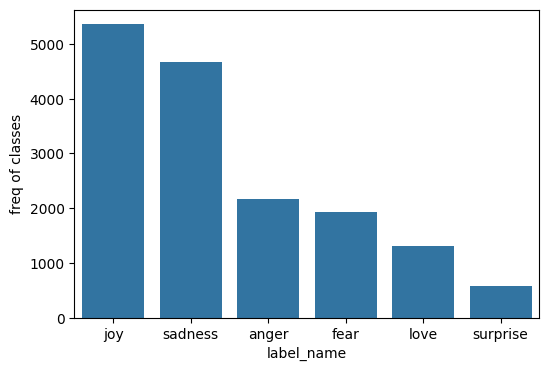

In [70]:
label_count= df['label_name'].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(x=label_count.index, y=label_count.values)
plt.ylabel("freq of classes")
plt.show()

#Imbalanced dataset(but transformer worrk well on imbalanced dataset also)

In [71]:
#Check the len of the each rows
df['words per tweet']=df['text'].str.split().apply(len)
df.head()

,text,label,label_name,words per tweet
0,i didnt feel humiliated,0,sadness,4
1,i can go from feeling so hopeless to so damned...,0,sadness,21
2,im grabbing a minute to post i feel greedy wrong,3,anger,10
3,i am ever feeling nostalgic about the fireplac...,2,love,18
4,i am feeling grouchy,3,anger,4


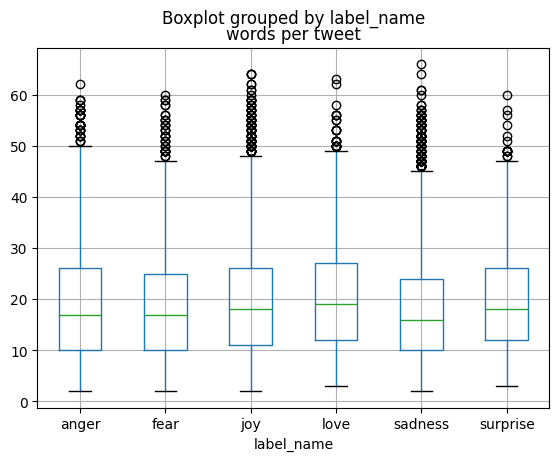

In [72]:
df.boxplot("words per tweet",by ='label_name')
plt.show()

# Apply the Transforemr

In [73]:
from transformers import AutoTokenizer
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [74]:
text = 'Artificial Intelligence is learn from data, and make the prediction'
encoded =tokenizer(text)
encoded

{'input_ids': [101, 7976, 4454, 2003, 4553, 2013, 2951, 1010, 1998, 2191, 1996, 17547, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [75]:

token =tokenizer.convert_ids_to_tokens(encoded['input_ids'])
print(token)

['[CLS]', 'artificial', 'intelligence', 'is', 'learn', 'from', 'data', ',', 'and', 'make', 'the', 'prediction', '[SEP]']


In [76]:
#toekn size
tokenizer.vocab_size

30522

In [77]:
#max len of the toeken can process
tokenizer.model_max_length

512

In [78]:
df=ds.load_dataset("emotion")
df

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [79]:
# Convert text to token
def convert_text_to_token(example):
  return tokenizer(example['text'],padding=True, truncation=True)

df_encoded = df.map(convert_text_to_token,batched=True, batch_size =None)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [80]:
df_encoded

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

# fine tuning transformer

In [81]:
num_class=len(class_label)
num_class

6

In [82]:
# Fine tune the transoformer
from transformers import AutoModelForSequenceClassification
import torch

device =torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_class).to(device)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [83]:
from transformers import TrainingArguments
model_name = "distilbirt-finetuned-emotion"
training_arg =TrainingArguments(output_dir =model_name,
                                num_train_epochs =6,
                                learning_rate = 2e-5,
                                per_device_train_batch_size =32,
                                per_device_eval_batch_size =32,
                                weight_decay =0.01,
                                disable_tqdm =False
                                )

In [95]:
#evalution
from sklearn.metrics import accuracy_score, f1_score
def acc_metrics(pred):
  labels =pred.label_ids
  prediction =pred.predictions.argmax(-1)
  f1 =f1_score(labels, prediction, average ='weighted')
  acc =accuracy_score(labels, prediction)
  return {'f1': f1, 'accuracy': acc}

In [87]:
from transformers import Trainer, DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer =Trainer(model =model,
                 args =training_arg,
                 compute_metrics =acc_metrics,
                 train_dataset =df_encoded['train'],
                 eval_dataset =df_encoded['validation'],
                 data_collator=data_collator)

In [88]:
trainer.train()

Step,Training Loss
500,0.574613
1000,0.155788
1500,0.105487
2000,0.079732
2500,0.061639
3000,0.047184


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3000, training_loss=0.17074047470092774, metrics={'train_runtime': 1606.436, 'train_samples_per_second': 59.76, 'train_steps_per_second': 1.867, 'total_flos': 4292153235072000.0, 'train_loss': 0.17074047470092774, 'epoch': 6.0})

# Prediction

In [108]:
text = 'I am learning AI.'
input_encoded = tokenizer(text, return_tensors ='pt', ).to(device)

with torch.no_grad():
  output =model(**input_encoded)
  prediction =output.logits.argmax(-1)
  print(prediction,class_label[prediction])


tensor([1], device='cuda:0') joy
